In [1]:
import pandas as pd

In [2]:
df_maintain = pd.read_csv('EV_Predictive_Maintenance_Dataset_15min.csv')
df_maintain.head()

,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260


In [3]:
df_maintain.shape

(175393, 30)

In [4]:
df_maintain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175393 entries, 0 to 175392
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Timestamp               175393 non-null  object 
 1   SoC                     175393 non-null  float64
 2   SoH                     175393 non-null  float64
 3   Battery_Voltage         175393 non-null  float64
 4   Battery_Current         175393 non-null  float64
 5   Battery_Temperature     175393 non-null  float64
 6   Charge_Cycles           175393 non-null  float64
 7   Motor_Temperature       175393 non-null  float64
 8   Motor_Vibration         175393 non-null  float64
 9   Motor_Torque            175393 non-null  float64
 10  Motor_RPM               175393 non-null  float64
 11  Power_Consumption       175393 non-null  float64
 12  Brake_Pad_Wear          175393 non-null  float64
 13  Brake_Pressure          175393 non-null  float64
 14  Reg_Brake_Efficiency

In [5]:
df_maintain.isnull().sum()

,0
Timestamp,0
SoC,0
SoH,0
Battery_Voltage,0
Battery_Current,0
Battery_Temperature,0
Charge_Cycles,0
Motor_Temperature,0
Motor_Vibration,0
Motor_Torque,0


In [6]:
df_maintain.duplicated().sum()

np.int64(0)

In [7]:
df_maintain['Timestamp'] = pd.to_datetime(df_maintain['Timestamp'])

In [9]:
df_maintain.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,175393,2022-07-02 12:00:00.000000512,2020-01-01 00:00:00,2021-04-01 18:00:00,2022-07-02 12:00:00,2023-10-02 06:00:00,2025-01-01 00:00:00,NaN
SoC,175393.0,0.779882,0.000006,0.823508,0.88238,0.941148,0.999999,0.29166
SoH,175393.0,0.882219,0.400001,0.911699,0.941193,0.97072,0.999999,0.164805
Battery_Voltage,175393.0,352.713482,200.001095,355.989733,370.587405,385.262527,399.999314,55.246513
Battery_Current,175393.0,-47.892493,-199.994036,-45.270093,-33.51835,-21.757595,-10.000173,45.358339
Battery_Temperature,175393.0,33.399346,25.00001,27.94817,30.887664,33.826187,59.99757,8.655192
Charge_Cycles,175393.0,217.685124,100.000809,129.489301,158.901349,188.31259,699.99692,164.506573
Motor_Temperature,175393.0,56.027332,40.000182,45.872695,51.757365,57.678209,99.999997,15.447305
Motor_Vibration,175393.0,0.523942,0.2,0.288583,0.376488,0.465118,1.999954,0.434352
Motor_Torque,175393.0,179.786407,100.000039,129.469691,158.810055,188.025425,399.998498,76.767046


In [10]:
df_maintain.nunique()

,0
Timestamp,175393
SoC,175393
SoH,175393
Battery_Voltage,175393
Battery_Current,175393
Battery_Temperature,175393
Charge_Cycles,175393
Motor_Temperature,175393
Motor_Vibration,175393
Motor_Torque,175393


In [11]:
df_maintain['SoC(%)'] = df_maintain['SoC']*100
df_maintain['SoH(%)'] = df_maintain['SoH']*100

In [13]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [14]:
df_maintain['component_health(%)'] = df_maintain['Component_Health_Score']*100

In [15]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [16]:
df_maintain['Brake_Wear(%)'] = df_maintain['Brake_Pad_Wear']*100

In [17]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [22]:
df_maintain['Reg_Brak(%)'] = df_maintain['Reg_Brake_Efficiency']*100

In [23]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [27]:
df_maintain['Failure_Status'] = df_maintain['Failure_Probability'].map({0:'No Failure' ,1:'No Failure'})

In [28]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [30]:
df_maintain['Date'] = df_maintain['Timestamp'].dt.date
df_maintain['Hour'] = df_maintain['Timestamp'].dt.hour
df_maintain['Day'] = df_maintain['Timestamp'].dt.hour
df_maintain['Month'] = df_maintain['Timestamp'].dt.month
df_maintain['Year'] = df_maintain['Timestamp'].dt.year

In [31]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [32]:
df_maintain.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,175393,2022-07-02 12:00:00.000000512,2020-01-01 00:00:00,2021-04-01 18:00:00,2022-07-02 12:00:00,2023-10-02 06:00:00,2025-01-01 00:00:00,NaN
SoC,175393.0,0.779882,0.000006,0.823508,0.88238,0.941148,0.999999,0.29166
SoH,175393.0,0.882219,0.400001,0.911699,0.941193,0.97072,0.999999,0.164805
Battery_Voltage,175393.0,352.713482,200.001095,355.989733,370.587405,385.262527,399.999314,55.246513
Battery_Current,175393.0,-47.892493,-199.994036,-45.270093,-33.51835,-21.757595,-10.000173,45.358339
Battery_Temperature,175393.0,33.399346,25.00001,27.94817,30.887664,33.826187,59.99757,8.655192
Charge_Cycles,175393.0,217.685124,100.000809,129.489301,158.901349,188.31259,699.99692,164.506573
Motor_Temperature,175393.0,56.027332,40.000182,45.872695,51.757365,57.678209,99.999997,15.447305
Motor_Vibration,175393.0,0.523942,0.2,0.288583,0.376488,0.465118,1.999954,0.434352
Motor_Torque,175393.0,179.786407,100.000039,129.469691,158.810055,188.025425,399.998498,76.767046


In [33]:
def battery_health(x):
  if x >= 95:
    return 'Excellent'
  elif x >= 90:
    return 'Good'
  elif x >= 80:
    return 'Moderate'
  else:
    return 'Poor'

df_maintain['Battery_Health'] = df_maintain['SoC(%)'].apply(battery_health)

In [34]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [39]:
def component_health(x):
  if x >= 95:
    return 'Excellent'
  elif x >= 90:
    return 'Good'
  elif x >= 80:
    return 'Moderate'
  else:
    return 'Poor'

df_maintain['Component_Health'] = df_maintain['component_health(%)'].apply(component_health)

In [40]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [42]:
df_maintain['Component_Health'].value_counts()

,count
Component_Health,
Poor,76210
Moderate,49476
Excellent,24904
Good,24803


In [44]:
def driving(speed):
  if speed < 50:
    return 'City'
  elif speed < 90:
    return 'Urban'
  else:
    return 'Highway'
df_maintain['Driving_Condition'] = df_maintain['Driving_Speed'].apply(driving)

In [45]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [46]:
def battery_temp(temp):
  if temp < 35:
    return 'Normal'
  elif temp < 45:
    return 'Warm'
  else:
    return 'High'
df_maintain['Battery_Status'] = df_maintain['Battery_Temperature'].apply(battery_temp)

In [47]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [54]:
q1 = df_maintain['RUL'].quantile(0.25)
q2 = df_maintain['RUL'].quantile(0.50)
q3 = df_maintain['RUL'].quantile(0.75)

def priority(rul):
  if rul <=  q1:
    return 'Critical'
  elif rul <= q2:
    return 'High'
  elif rul < q3:
    return 'Medium'
  else:
    return 'Low'
df_maintain['Priority'] = df_maintain['RUL'].apply(priority)

In [55]:
df_maintain.head().T

,0,1,2,3,4
Timestamp,2020-01-01 00:00:00,2020-01-01 00:15:00,2020-01-01 00:30:00,2020-01-01 00:45:00,2020-01-01 01:00:00
SoC,0.826099,0.064728,0.873643,0.853009,0.94754
SoH,0.941338,0.916059,0.90802,0.916476,0.913206
Battery_Voltage,210.163881,364.000102,388.855089,370.570602,390.011904
Battery_Current,-22.753095,-27.70112,-36.646406,-37.609429,-14.275808
Battery_Temperature,27.149201,53.655101,29.55909,29.690283,28.864338
Charge_Cycles,149.19093,171.702388,191.617645,111.881817,163.774377
Motor_Temperature,48.496049,57.829492,46.518363,54.163681,42.075978
Motor_Vibration,0.369095,1.449195,1.859045,0.3815,0.433927
Motor_Torque,113.435589,105.58716,119.610302,182.535625,173.298044


In [56]:
df_maintain['Priority'].value_counts()

,count
Priority,
Critical,43849
Low,43849
High,43848
Medium,43847


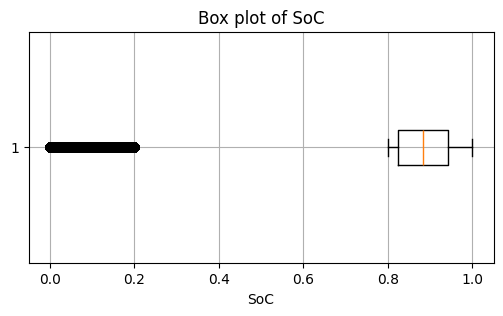

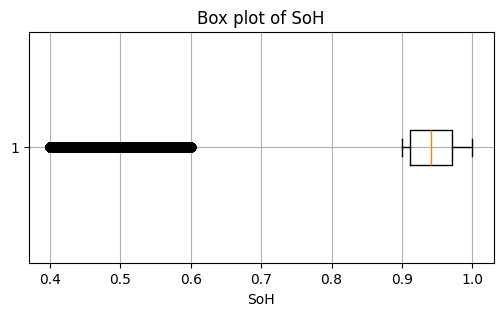

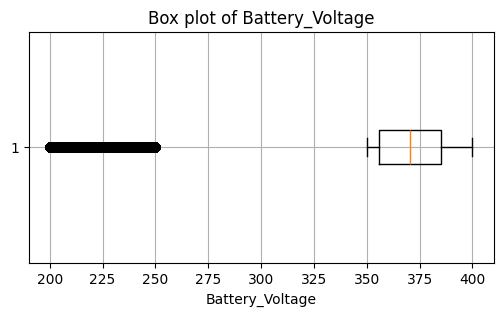

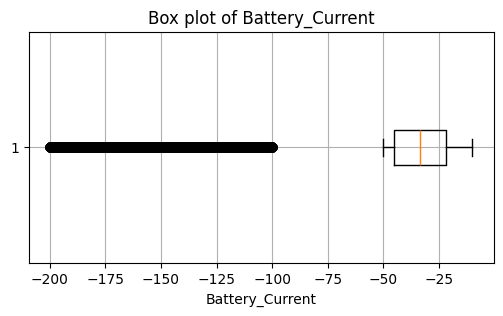

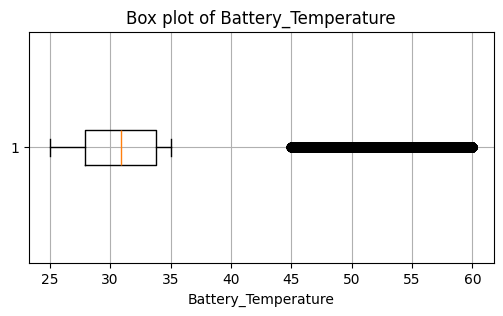

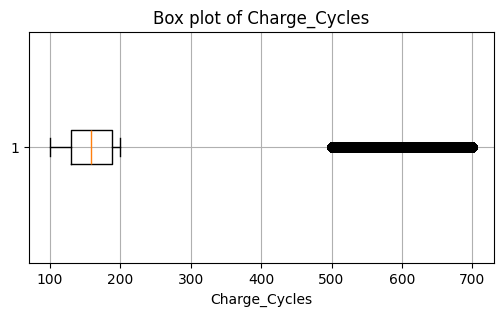

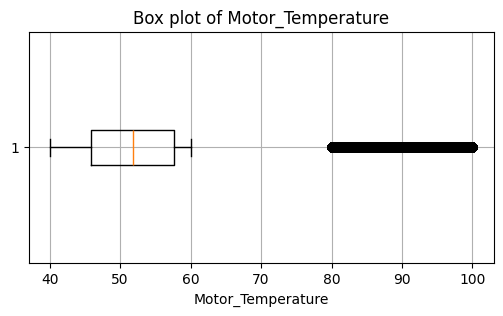

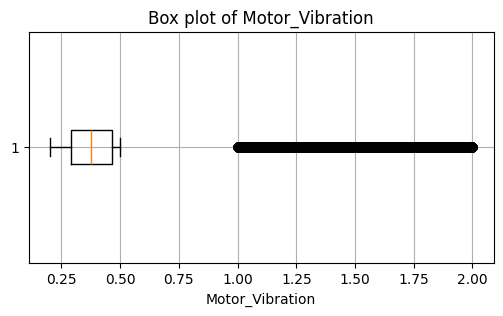

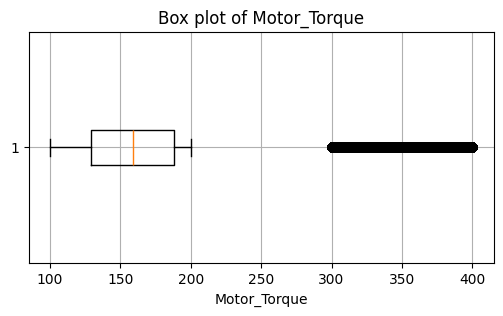

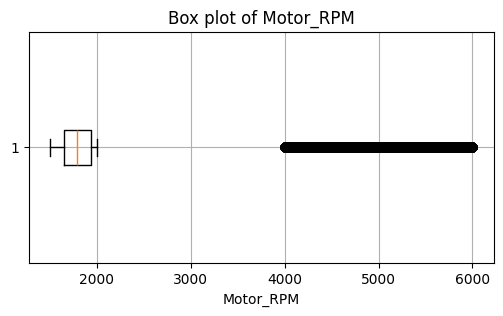

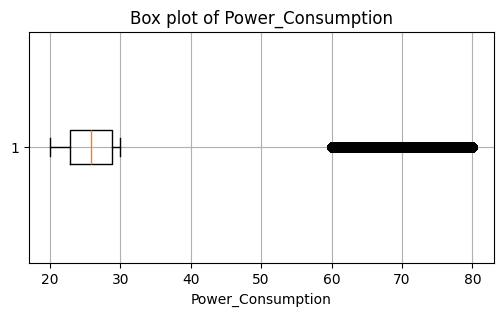

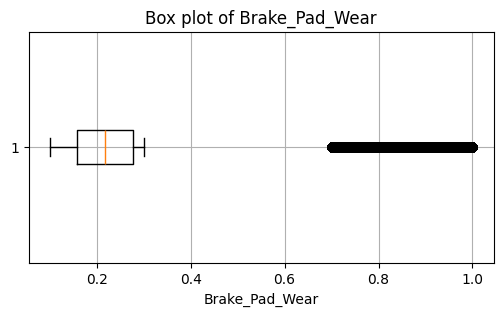

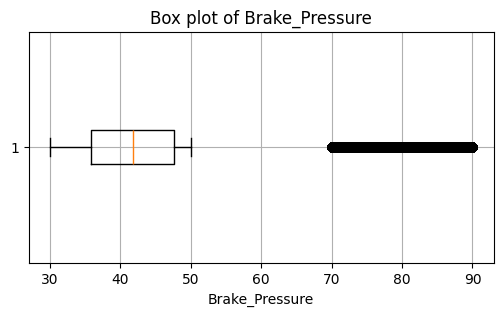

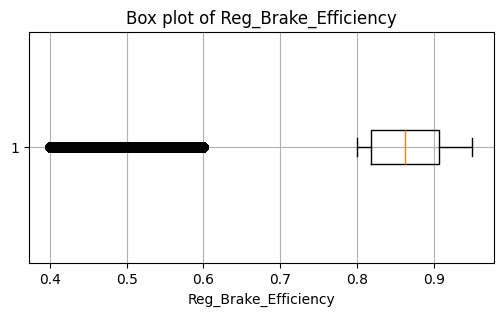

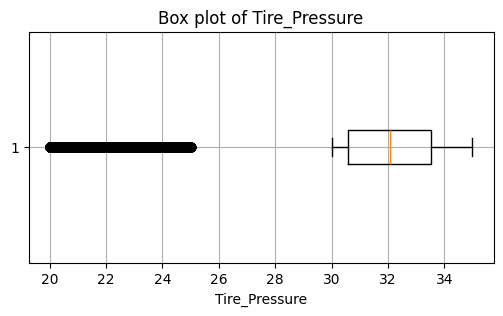

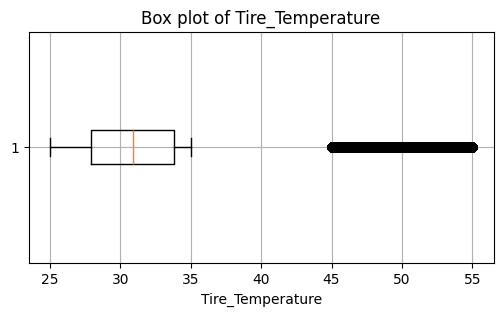

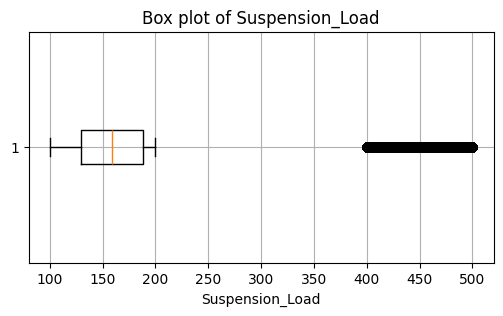

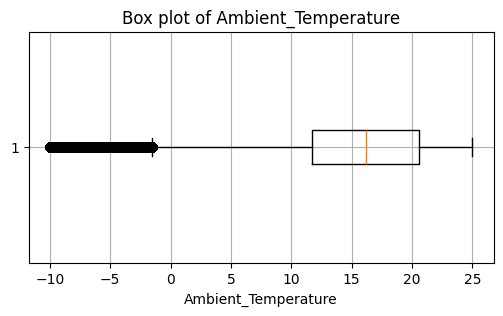

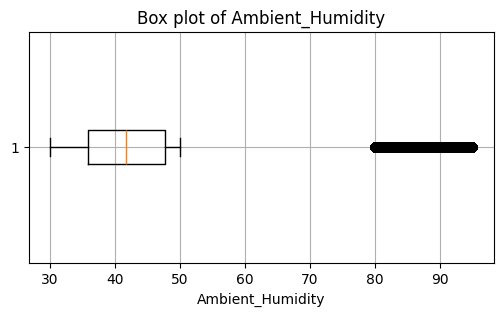

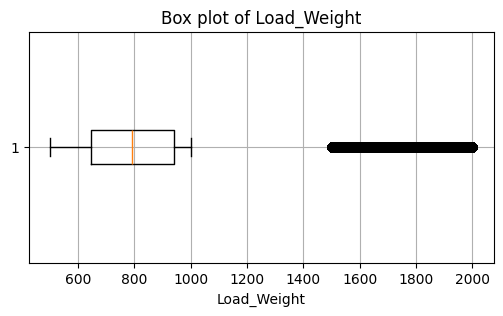

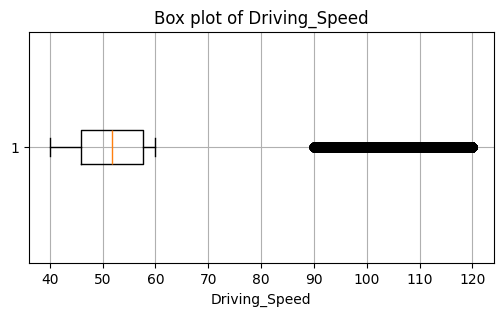

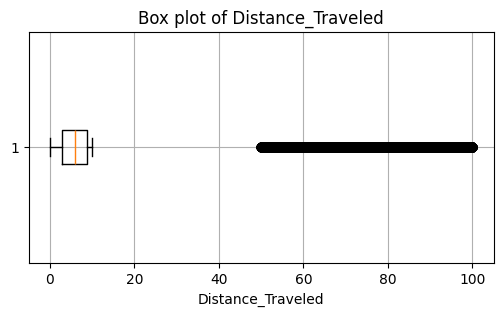

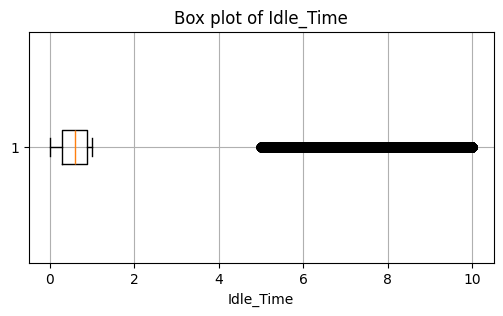

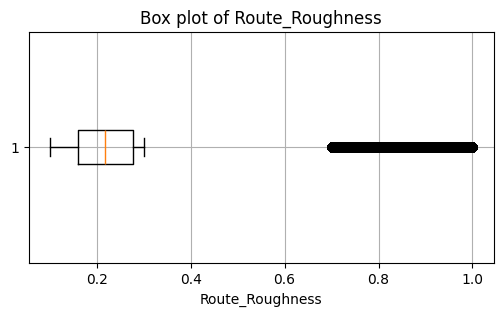

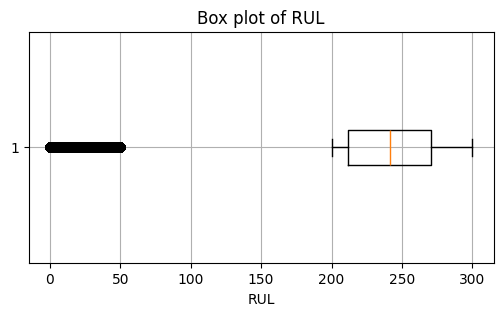

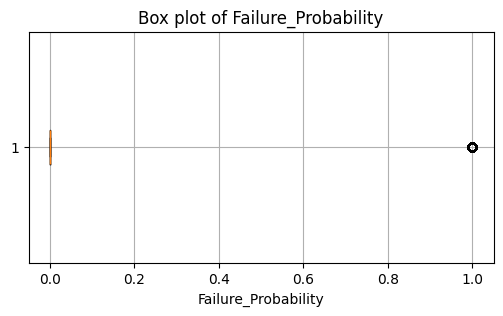

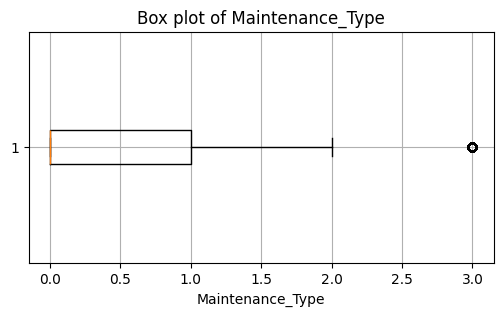

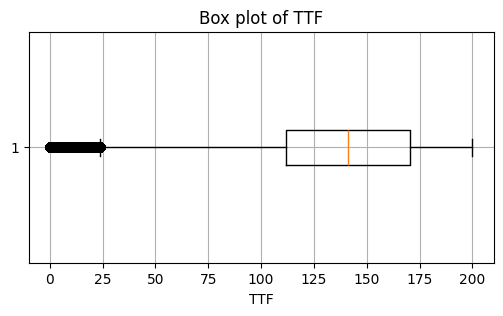

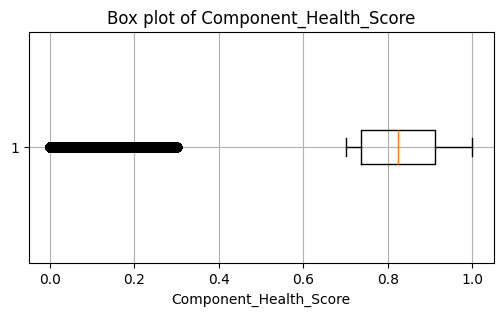

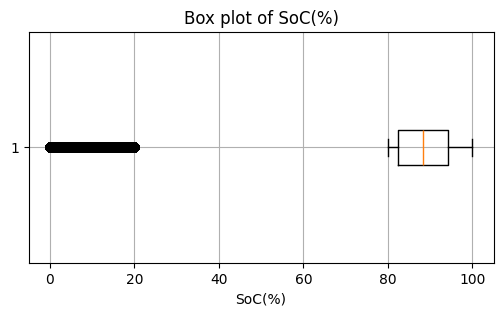

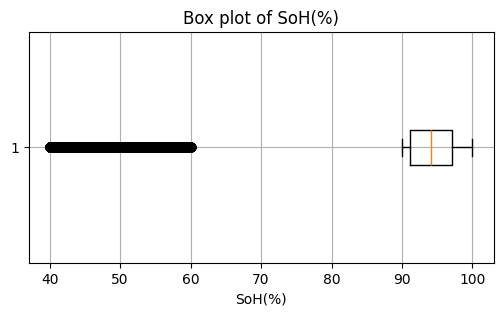

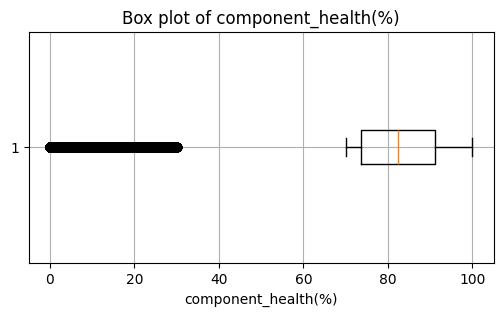

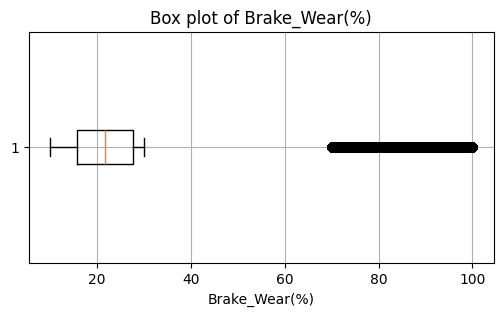

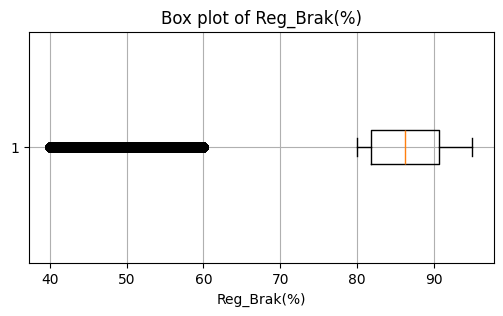

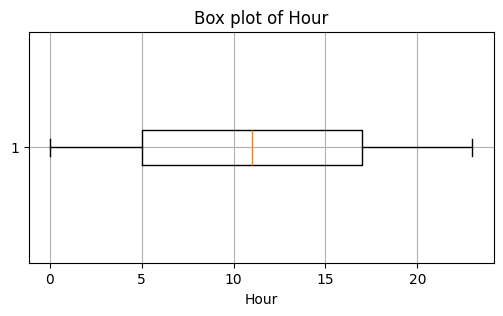

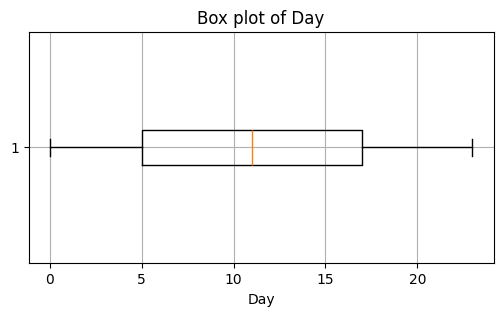

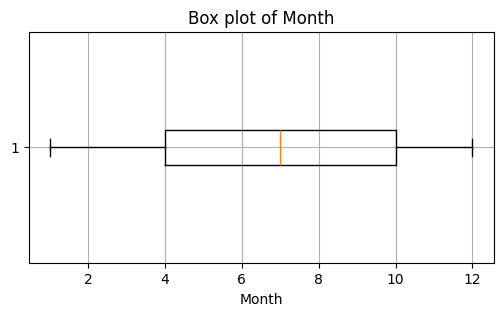

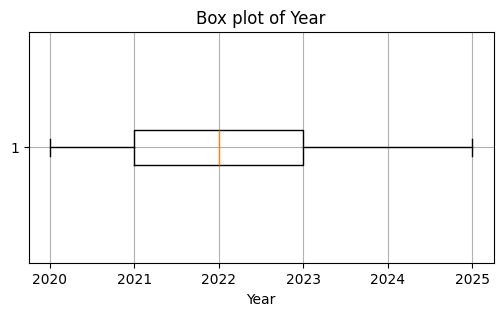

In [57]:
# Boxing Plot
import matplotlib.pyplot as plt

num_cols = df_maintain.select_dtypes(include=['int64','float64','int32','float32']).columns

for col in num_cols:
  plt.figure(figsize=(6,3))
  plt.boxplot(df_maintain[col], vert= False)
  plt.title(f'Box plot of {col}')
  plt.xlabel(col)
  plt.grid(True)
  plt.show()

In [58]:
outlier_count = {}

for col in num_cols:
  Q1 = df_maintain[col].quantile(0.25)
  Q3 = df_maintain[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  count = ((df_maintain[col] < lower_bound) | (df_maintain[col] > upper_bound)).sum()
  outlier_count[col] = count
outlier_df = pd.DataFrame(outlier_count.items(), columns=['Column', 'Outlier Count'])
outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)
print(outlier_df)

                    Column  Outlier Count
7          Motor_Vibration          26606
28  Component_Health_Score          26539
31     component_health(%)          26539
16         Suspension_Load          26525
6        Motor_Temperature          26511
12          Brake_Pressure          26486
4      Battery_Temperature          26481
1                      SoH          26433
30                  SoH(%)          26433
11          Brake_Pad_Wear          26423
32           Brake_Wear(%)          26423
22               Idle_Time          26417
19             Load_Weight          26364
5            Charge_Cycles          26354
0                      SoC          26320
29                  SoC(%)          26320
18        Ambient_Humidity          26316
14           Tire_Pressure          26264
20           Driving_Speed          26257
15        Tire_Temperature          26248
23         Route_Roughness          26247
3          Battery_Current          26220
33             Reg_Brak(%)        

In [59]:
outlier_df['Outlier_Percentage'] = (outlier_df['Outlier Count'] / len(df_maintain)) * 100

In [60]:
outlier_df

,Column,Outlier Count,Outlier_Percentage
7,Motor_Vibration,26606,15.169363
28,Component_Health_Score,26539,15.131163
31,component_health(%),26539,15.131163
16,Suspension_Load,26525,15.123181
6,Motor_Temperature,26511,15.115198
12,Brake_Pressure,26486,15.100945
4,Battery_Temperature,26481,15.098094
1,SoH,26433,15.070727
30,SoH(%),26433,15.070727
11,Brake_Pad_Wear,26423,15.065025


In [61]:
df_maintain.to_csv('predict_clean.csv')